# Model Selection Benchmark — Bank Account Fraud (BAF)

**Objetivo:** Probar rápidamente múltiples modelos sobre el **10% estratificado** del train
para obtener un ranking de Average Precision (AP) y decidir en qué modelos invertir
tiempo de optimización posterior.

-  **Métrica principal:** `Average Precision (PR-AUC)` — correcta para desbalanceo extremo (~1% fraude).  
- **No se usa Accuracy.**


## 1 · Importaciones

Se importan las librerías necesarias.

Se definen también las constantes globales `RANDOM_STATE` y `TARGET_COL`.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedShuffleSplit,
    GridSearchCV,
    cross_val_score,
)

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42
TARGET_COL   = 'fraud_bool'

## 2 · Carga del dataset y splits

Se carga el dataset preprocesado (`base-limpia.csv`) y se realiza una primera división estratificada **80% train / 20% test**, preservando la proporción de fraude en ambos conjuntos.

In [2]:
df = pd.read_csv('base-limpia.csv')

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Tasa de fraude global: {df[TARGET_COL].mean()*100:.2f}%')
print()

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Train completo : {X_train_full.shape[0]:,} muestras '
      f'({y_train_full.mean()*100:.2f}% fraude)')
print(f'Test           : {X_test.shape[0]:,} muestras '
      f'({y_test.mean()*100:.2f}% fraude)')


Dataset cargado: 1,000,000 filas × 48 columnas
Tasa de fraude global: 1.10%

Train completo : 800,000 muestras (1.10% fraude)
Test           : 200,000 muestras (1.10% fraude)


### 2.1 · Subsplit del 10% para el benchmark

Para agilizar la búsqueda de hiperparámetros, se extrae un **10% estratificado del train completo**. Este subconjunto es el único que toca GridSearch. El test del 20% original permanece intacto y se usa únicamente para evaluación final, evitando *data leakage*.

In [3]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.90, random_state=RANDOM_STATE)
for idx_small, _ in sss.split(X_train_full, y_train_full):
    X_train = X_train_full.iloc[idx_small].reset_index(drop=True)
    y_train = y_train_full.iloc[idx_small].reset_index(drop=True)

ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Train submuestreado (10%) : {X_train.shape[0]:,} muestras '
      f'({y_train.mean()*100:.2f}% fraude)')
print(f'Ratio desbalance (0:1)    : {ratio_desbalance:.1f}:1')
print()
print('NOTA: X_test es el 20% ORIGINAL — no toca el 10% de GridSearch.')

Train submuestreado (10%) : 80,000 muestras (1.10% fraude)
Ratio desbalance (0:1)    : 89.7:1

NOTA: X_test es el 20% ORIGINAL — no toca el 10% de GridSearch.


## 3 · Funciones auxiliares de evaluación

Se definen dos funciones reutilizables que se invocarán para cada modelo tras el entrenamiento.

### 3.1 · `find_best_threshold` — umbral óptimo de F1

Recorre la curva Precision-Recall y devuelve el umbral de clasificación que **maximiza el F1**. Necesario porque en problemas desbalanceados el umbral por defecto (0.5) suele ser subóptimo.

In [4]:
def find_best_threshold(y_true, y_proba):
    """Umbral que maximiza F1 en la curva Precision-Recall."""
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    f1  = 2 * (prec * rec) / (prec + rec + 1e-10)
    idx = np.argmax(f1[:-1])
    return float(thr[idx]) if len(thr) > idx else 0.5

### 3.2 · `evaluate_on_test` — evaluación completa sobre test

Evalúa un pipeline ya entrenado sobre `X_test` y devuelve un diccionario con las métricas principales: **AP**, **ROC-AUC**, **F1**, **Recall** y **Precision**.

Acepta tanto modelos con `predict_proba` como `LinearSVC` (que usa `decision_function`).

In [5]:
def evaluate_on_test(name, pipeline_or_model, use_decision_function=False):
    """
    Evalúa un pipeline/modelo ya entrenado sobre X_test.
    Devuelve un dict con las métricas principales.

    - use_decision_function=True  → para LinearSVC (no tiene predict_proba)
    - use_decision_function=False → para todos los demás
    """
    if use_decision_function:
        y_score = pipeline_or_model.decision_function(X_test)
    else:
        y_score = pipeline_or_model.predict_proba(X_test)[:, 1]

    ap      = average_precision_score(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)

    thr    = find_best_threshold(y_test, y_score)
    y_pred = (y_score >= thr).astype(int)

    f1   = f1_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)

    print(f'  TEST → AP={ap:.4f} | ROC-AUC={roc_auc:.4f} | '
          f'F1={f1:.4f} | Recall={rec:.4f} | Precision={prec:.4f}')

    return {
        'Modelo':     name,
        'AP_CV':      None,          
        'AP_test':    round(ap, 4),
        'ROC-AUC':    round(roc_auc, 4),
        'F1':         round(f1, 4),
        'Recall':     round(rec, 4),
        'Precision':  round(prec, 4),
        'Threshold':  round(thr, 4),
        '_y_score':   y_score,       
    }

## 4 · Definición de pipelines y grids de hiperparámetros

Cada modelo se envuelve en un **`ImbPipeline`** con dos pasos fijos:

| Paso | Clase | Por qué |
|------|-------|---------|
| `smote` | `SMOTE(sampling_strategy=0.1)` | Sobremuestreo sintético **solo dentro de CV** |
| `model` | *(variable)* | El clasificador en cuestión |

- `ImbPipeline` de **imblearn** garantiza que SMOTE **nunca se aplica** en `.predict_proba()`, solo en `.fit()`. Así no hay *data leakage*.
- Los modelos boosting nativos (`XGBoost`, `LightGBM`, `CatBoost`, `GradientBoosting`, `HistGradientBoosting`) gestionan el desbalance internamente mediante `scale_pos_weight` o `class_weight`, por lo que no necesitan SMOTE.
- `LinearSVC` no tiene `predict_proba` nativo → se calibra con `CalibratedClassifierCV`.

### 4.1 · Helpers de construcción de pipelines y catálogo de modelos

Se definen dos helpers (`make_pipeline_smote`, `make_pipeline_native`) y se construye el `MODEL_CATALOG`: un diccionario que asocia a cada modelo su pipeline, su grid de hiperparámetros y el número de folds de CV.

In [6]:
def make_pipeline_smote(model):
    return ImbPipeline(steps=[
        ('smote',  SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)), 
        ('model',  model),
    ])

def make_pipeline_native(model):
    return ImbPipeline(steps=[
        ('model',  model),
    ])


MODEL_CATALOG = {

    'LinearSVC': {
        'pipeline': make_pipeline_smote(
            CalibratedClassifierCV(
                LinearSVC(class_weight='balanced', dual='auto',
                          max_iter=5000, random_state=RANDOM_STATE),
                cv=3,
            )
        ),
        'grid': {'model__estimator__C': [0.01, 0.1, 1.0]},
        'cv':   3,
    },

    'DecisionTree': {
        'pipeline': make_pipeline_smote(
            DecisionTreeClassifier(random_state=RANDOM_STATE) 
        ),
        'grid': {
            'model__max_depth':       [5, 10, 20],
            'model__min_samples_leaf':[5, 10],
            'model__ccp_alpha':       [0.0, 0.001],
        },
        'cv': 3,
    },

    'RandomForest': {
        'pipeline': make_pipeline_smote(
            RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE) 
        ),
        'grid': {
            'model__n_estimators': [100, 200],
            'model__max_depth':    [10, 20, None],
            'model__min_samples_leaf': [5, 10],
        },
        'cv': 3,
    },

    'AdaBoost': {
        'pipeline': make_pipeline_smote(
            AdaBoostClassifier(
                estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
                random_state=RANDOM_STATE,
            )
        ),
        'grid': {
            'model__n_estimators':  [100, 200],
            'model__learning_rate': [0.1, 0.5, 1.0],
        },
        'cv': 3,
    },

    'XGBoost': {
        'pipeline': make_pipeline_native(
            XGBClassifier(
                scale_pos_weight=ratio_desbalance,
                eval_metric='aucpr',
                n_jobs=-1,
                verbosity=0,
                random_state=RANDOM_STATE,
            )
        ),
        'grid': {
            'model__n_estimators':  [100, 200],
            'model__max_depth':     [3, 5],
            'model__learning_rate': [0.05, 0.1],
            'model__subsample':     [0.8],
        },
        'cv': 3,
    },

    'LightGBM': {
        'pipeline': make_pipeline_native(
            LGBMClassifier(
                scale_pos_weight=ratio_desbalance,
                n_jobs=-1,
                verbosity=-1,
                random_state=RANDOM_STATE,
            )
        ),
        'grid': {
            'model__n_estimators':    [100, 200],
            'model__num_leaves':      [31, 63],
            'model__learning_rate':   [0.05, 0.1],
            'model__colsample_bytree':[0.8, 1.0],
        },
        'cv': 3,
    },

    'CatBoost': {
        'pipeline': make_pipeline_native(
            CatBoostClassifier(
                scale_pos_weight=ratio_desbalance,
                eval_metric='PRAUC',
                thread_count=-1,
                verbose=False,
                random_seed=RANDOM_STATE,
            )
        ),
        'grid': {
            'model__iterations':    [200, 400],
            'model__depth':         [4, 6],
            'model__learning_rate': [0.05, 0.1],
        },
        'cv': 3,
    },
    'GradientBoosting': {
    'pipeline': make_pipeline_native(
        GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        )
    ),
    'grid': {
        'model__n_estimators':  [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth':     [3, 5],
        'model__subsample':     [0.8, 1.0],
    },
    'cv': 3,
},
    'HistGradientBoosting': {
    'pipeline': make_pipeline_native(
        HistGradientBoostingClassifier(
            class_weight='balanced',  
            random_state=RANDOM_STATE,
        )
    ),
    'grid': {
        'model__max_iter': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [3, 5],
    },
    'cv': 3,
},
}

### 4.2 · Resumen de combinaciones por modelo

Se imprime cuántas combinaciones de hiperparámetros se probarán por modelo y el total de fits resultantes (combinaciones × folds CV).

In [7]:
print(f'{len(MODEL_CATALOG)} pipelines definidos:')
for name, cfg in MODEL_CATALOG.items():
    n_combis = 1
    for v in cfg['grid'].values():
        n_combis *= len(v)
    print(f'   {name:<15} → {n_combis:>3} combinaciones × CV={cfg["cv"]} '
          f'= {n_combis * cfg["cv"]:>4} fits')

9 pipelines definidos:
   LinearSVC       →   3 combinaciones × CV=3 =    9 fits
   DecisionTree    →  12 combinaciones × CV=3 =   36 fits
   RandomForest    →  12 combinaciones × CV=3 =   36 fits
   AdaBoost        →   6 combinaciones × CV=3 =   18 fits
   XGBoost         →   8 combinaciones × CV=3 =   24 fits
   LightGBM        →  16 combinaciones × CV=3 =   48 fits
   CatBoost        →   8 combinaciones × CV=3 =   24 fits
   GradientBoosting →  16 combinaciones × CV=3 =   48 fits
   HistGradientBoosting →   8 combinaciones × CV=3 =   24 fits


## 5 · GridSearch sobre el 10% del train

Se ejecuta `GridSearchCV` con `scoring='average_precision'` sobre cada modelo del catálogo. Al finalizar cada búsqueda, el mejor estimador se evalúa directamente sobre el **test del 20% original** mediante `evaluate_on_test`.

Los resultados y los objetos `GridSearchCV` se almacenan en `all_results` y `trained_grids` respectivamente para su análisis posterior.

In [8]:
all_results   = []
trained_grids = {}   

print('=' * 65)
print(f'  BENCHMARK — GridSearch sobre {X_train.shape[0]:,} muestras (10% train)')
print('=' * 65)

for name, cfg in MODEL_CATALOG.items():
    print(f'\n- {name}')
    t0 = time.time()

    gs = GridSearchCV(
        estimator  = cfg['pipeline'],
        param_grid = cfg['grid'],
        cv         = cfg['cv'],
        scoring    = 'average_precision',
        n_jobs     = -1,
        refit      = True,     
        verbose    = 0,
    )
    gs.fit(X_train, y_train)

    elapsed = time.time() - t0
    print(f'  Mejores params : {gs.best_params_}')
    print(f'  AP CV (10%)    : {gs.best_score_:.4f} | Tiempo: {elapsed:.1f}s')

    result = evaluate_on_test(name, gs.best_estimator_)
    result['AP_CV']   = round(gs.best_score_, 4)
    result['Tiempo_s'] = round(elapsed, 1)
    result['Params']   = str(gs.best_params_)

    all_results.append(result)
    trained_grids[name] = gs

print('\n' + '=' * 65)
print('  Benchmark completado.')
print('=' * 65)


  BENCHMARK — GridSearch sobre 80,000 muestras (10% train)

- LinearSVC
  Mejores params : {'model__estimator__C': 0.01}
  AP CV (10%)    : 0.0766 | Tiempo: 55.6s
  TEST → AP=0.0773 | ROC-AUC=0.8180 | F1=0.1623 | Recall=0.2484 | Precision=0.1206

- DecisionTree
  Mejores params : {'model__ccp_alpha': 0.0, 'model__max_depth': 10, 'model__min_samples_leaf': 10}
  AP CV (10%)    : 0.0413 | Tiempo: 17.0s
  TEST → AP=0.0387 | ROC-AUC=0.7300 | F1=0.0930 | Recall=0.2502 | Precision=0.0571

- RandomForest
  Mejores params : {'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
  AP CV (10%)    : 0.0940 | Tiempo: 62.6s
  TEST → AP=0.0900 | ROC-AUC=0.8463 | F1=0.1663 | Recall=0.2013 | Precision=0.1417

- AdaBoost
  Mejores params : {'model__learning_rate': 1.0, 'model__n_estimators': 200}
  AP CV (10%)    : 0.1085 | Tiempo: 76.2s
  TEST → AP=0.1086 | ROC-AUC=0.8581 | F1=0.1890 | Recall=0.2792 | Precision=0.1429

- XGBoost
  Mejores params : {'model__learning_rate': 

## 6 · Ranking final de modelos

Se construye un `DataFrame` ordenado por **AP en test** (métrica principal). Se añade la columna `Gap_CV-Test` para detectar posible *overfitting* en CV: valores altos (en rojo) indican que el modelo generaliza peor de lo esperado.

In [9]:
cols_show = ['Modelo','AP_CV','AP_test','ROC-AUC','F1',
             'Recall','Precision','Threshold','Tiempo_s','Params']

df_rank = (
    pd.DataFrame([{k: v for k,v in r.items() if not k.startswith('_')}
                  for r in all_results])
    [cols_show]
    .sort_values('AP_test', ascending=False)
    .reset_index(drop=True)
)
df_rank.index += 1   

df_rank['Gap_CV-Test'] = (df_rank['AP_CV'] - df_rank['AP_test']).round(4)

def highlight_top3(s):
    colors = []
    for i, _ in enumerate(s):
        if i == 0: colors.append('background-color: #f9e79f; font-weight: bold')
        elif i == 1: colors.append('background-color: #d5f5e3')
        elif i == 2: colors.append('background-color: #d6eaf8')
        else: colors.append('')
    return colors

def color_gap(val):
    if pd.isna(val): return ''
    if val > 0.02: return 'color: #e74c3c; font-weight: bold'  
    return 'color: #27ae60'

styled = (
    df_rank.style
    .apply(highlight_top3, subset=['AP_test'])
    .map(color_gap, subset=['Gap_CV-Test']) 
    .format({
        'AP_CV':       '{:.4f}',
        'AP_test':     '{:.4f}',
        'ROC-AUC':     '{:.4f}',
        'F1':          '{:.4f}',
        'Recall':      '{:.4f}',
        'Precision':   '{:.4f}',
        'Threshold':   '{:.4f}',
        'Gap_CV-Test': '{:+.4f}',
        'Tiempo_s':    '{:.1f}s',
    })
    .set_caption(' Ranking de modelos — 10% Train | Test 20% original')
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color','#2c3e50'),
                  ('color','white'), ('text-align','center')]
    }])
)

print('RANKING FINAL (ordenado por AP en Test)')
print('=' * 65)
print(df_rank[['Modelo','AP_CV','AP_test','F1','Recall','Tiempo_s']].to_string())
print('=' * 65)

styled


RANKING FINAL (ordenado por AP en Test)
                 Modelo   AP_CV  AP_test      F1  Recall  Tiempo_s
1              CatBoost  0.1553   0.1636  0.2379  0.2602      65.2
2               XGBoost  0.1465   0.1530  0.2315  0.2412       9.1
3  HistGradientBoosting  0.1366   0.1474  0.2271  0.2543      10.6
4      GradientBoosting  0.1354   0.1453  0.2263  0.2448     365.3
5              LightGBM  0.1300   0.1304  0.2091  0.2044      35.6
6              AdaBoost  0.1085   0.1086  0.1890  0.2792      76.2
7          RandomForest  0.0940   0.0900  0.1663  0.2013      62.6
8             LinearSVC  0.0766   0.0773  0.1623  0.2484      55.6
9          DecisionTree  0.0413   0.0387  0.0930  0.2502      17.0


,Modelo,AP_CV,AP_test,ROC-AUC,F1,Recall,Precision,Threshold,Tiempo_s,Params,Gap_CV-Test
1,CatBoost,0.1553,0.1636,0.8827,0.2379,0.2602,0.2192,0.8775,65.2s,"{'model__depth': 4, 'model__iterations': 400, 'model__learning_rate': 0.05}",-0.0083
2,XGBoost,0.1465,0.1530,0.8835,0.2315,0.2412,0.2226,0.8740,9.1s,"{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}",-0.0065
3,HistGradientBoosting,0.1366,0.1474,0.8784,0.2271,0.2543,0.2052,0.8627,10.6s,"{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__max_iter': 100}",-0.0108
4,GradientBoosting,0.1354,0.1453,0.8831,0.2263,0.2448,0.2104,0.0974,365.3s,"{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}",-0.0099
5,LightGBM,0.1300,0.1304,0.8580,0.2091,0.2044,0.2140,0.8758,35.6s,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__n_estimators': 100, 'model__num_leaves': 31}",-0.0004
6,AdaBoost,0.1085,0.1086,0.8581,0.1890,0.2792,0.1429,0.4857,76.2s,"{'model__learning_rate': 1.0, 'model__n_estimators': 200}",-0.0001
7,RandomForest,0.0940,0.0900,0.8463,0.1663,0.2013,0.1417,0.3155,62.6s,"{'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}",+0.0040
8,LinearSVC,0.0766,0.0773,0.8180,0.1623,0.2484,0.1206,0.3919,55.6s,{'model__estimator__C': 0.01},-0.0007
9,DecisionTree,0.0413,0.0387,0.7300,0.0930,0.2502,0.0571,0.2222,17.0s,"{'model__ccp_alpha': 0.0, 'model__max_depth': 10, 'model__min_samples_leaf': 10}",+0.0026


## 7 · Visualizaciones

Tres gráficos complementarios para analizar los resultados del benchmark.

### 7.1 · AP CV vs Test · F1/Recall/Precision · Curvas PR

Figura de tres paneles:
- **Izquierda**: comparativa de Average Precision en CV vs test por modelo.
- **Centro**: F1, Recall y Precision en test para cada modelo.
- **Derecha**: curvas Precision-Recall completas de todos los modelos sobre el test, con el mejor modelo destacado.

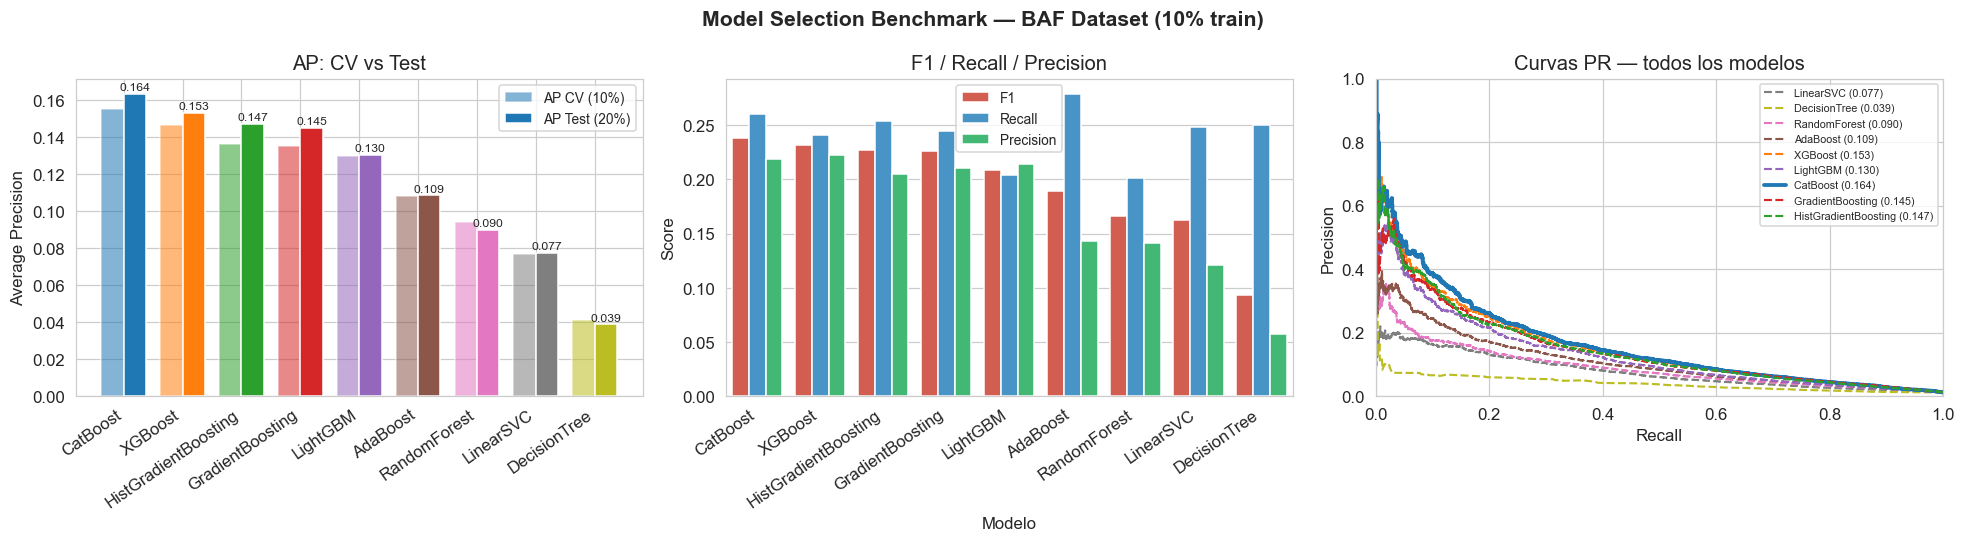

Gráfico guardado → benchmark_model_selection.png


In [10]:
modelos    = df_rank['Modelo'].tolist()
palette    = sns.color_palette('tab10', len(modelos))
color_map  = dict(zip(modelos, palette))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Selection Benchmark — BAF Dataset (10% train)',
             fontsize=14, fontweight='bold')

# Resultados principales: AP CV vs AP Test
ax = axes[0]
x  = np.arange(len(modelos))
w  = 0.38
bars_cv   = ax.bar(x - w/2, df_rank['AP_CV'],   width=w, label='AP CV (10%)',
                   color=[color_map[m] for m in modelos], alpha=0.55, edgecolor='white')
bars_test = ax.bar(x + w/2, df_rank['AP_test'], width=w, label='AP Test (20%)',
                   color=[color_map[m] for m in modelos], alpha=1.0,  edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(modelos, rotation=35, ha='right')
ax.set_ylabel('Average Precision'); ax.set_title('AP: CV vs Test')
ax.legend(fontsize=9)
for b in bars_test:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{b.get_height():.3f}', ha='center', fontsize=8)

# F1 / Recall / Precision por modelo
ax = axes[1]
df_melt = df_rank[['Modelo','F1','Recall','Precision']].melt(
    id_vars='Modelo', var_name='Metrica', value_name='Valor'
)
sns.barplot(data=df_melt, x='Modelo', y='Valor', hue='Metrica',
            palette=['#e74c3c','#3498db','#2ecc71'], ax=ax)
ax.set_xticklabels(modelos, rotation=35, ha='right')
ax.set_title('F1 / Recall / Precision'); ax.set_ylabel('Score')
ax.legend(fontsize=9)

# Curvas Precision-Recall por modelo
ax = axes[2]
for r in all_results:
    m    = r['Modelo']
    prec, rec, _ = precision_recall_curve(y_test, r['_y_score'])
    lw   = 2.5 if m == df_rank.iloc[0]['Modelo'] else 1.4
    ls   = '-'  if m == df_rank.iloc[0]['Modelo'] else '--'
    ax.plot(rec, prec, label=f"{m} ({r['AP_test']:.3f})",
            linewidth=lw, linestyle=ls, color=color_map[m])
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curvas PR — todos los modelos')
ax.legend(fontsize=7, loc='upper right')
ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.tight_layout()
plt.savefig('benchmark_model_selection.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico guardado → benchmark_model_selection.png')


### 7.2 · Distribución de scores predichos por clase

Violin plot que muestra, para cada modelo, cómo se distribuyen las probabilidades asignadas a las clases *Legítimo* y *Fraude*. Una buena separación entre ambas distribuciones indica mayor capacidad discriminativa del modelo.

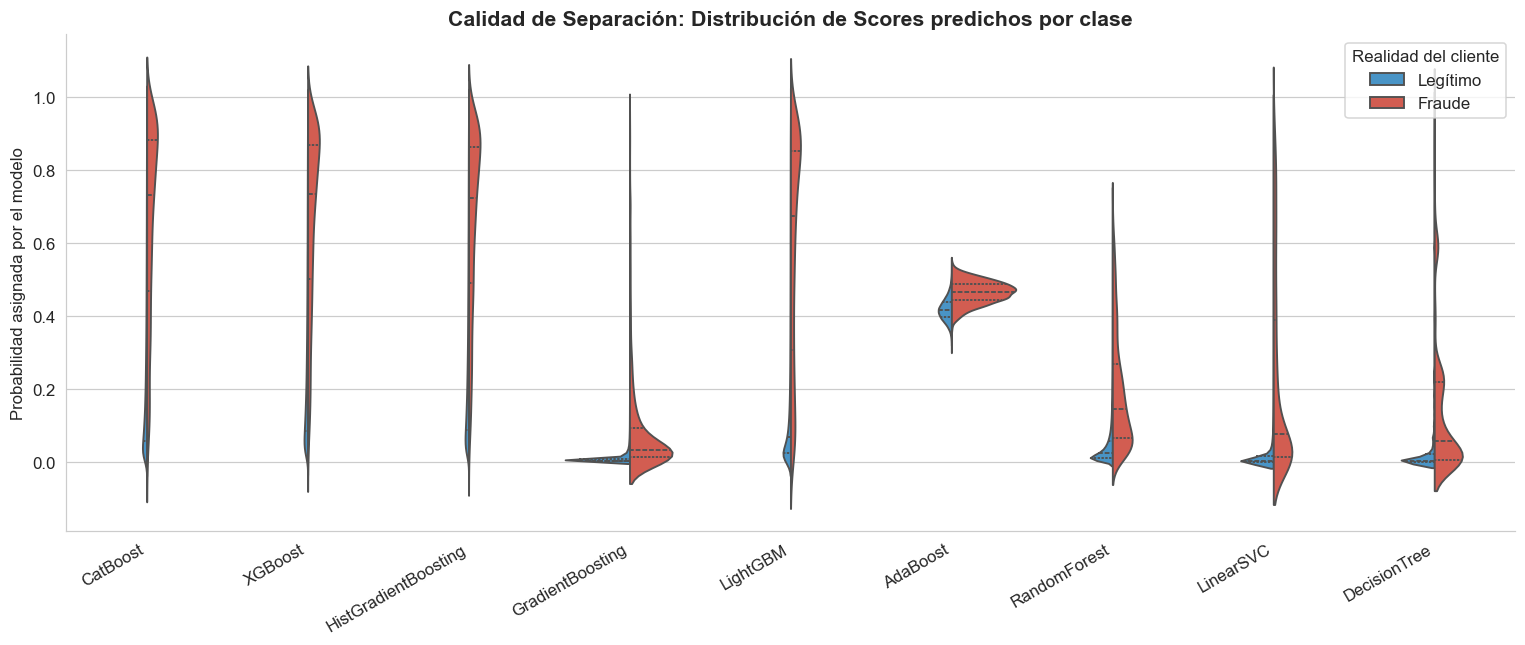

In [11]:
# Calidad de separación: Distribución de scores predichos por clase
plot_data = []
for r in all_results:
    m = r['Modelo']
    for score, true_label in zip(r['_y_score'], y_test):
        plot_data.append({
            'Modelo': m,
            'Score': score,
            'Clase': 'Fraude' if true_label == 1 else 'Legítimo'
        })
df_scores = pd.DataFrame(plot_data)

plt.figure(figsize=(14, 6))
sns.violinplot(
    data=df_scores, 
    x='Modelo', 
    y='Score', 
    hue='Clase', 
    split=True, 
    inner='quartile',
    palette={'Legítimo': '#3498db', 'Fraude': '#e74c3c'},
    order=modelos
)

plt.title('Calidad de Separación: Distribución de Scores predichos por clase', fontsize=14, fontweight='bold')
plt.ylabel('Probabilidad asignada por el modelo')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Realidad del cliente')
sns.despine()
plt.tight_layout()
plt.savefig('benchmark_distribucion_scores.png', dpi=150)
plt.show()

### 7.3 · Rendimiento vs. tiempo de entrenamiento

Scatter plot donde cada burbuja representa un modelo. El eje X es el tiempo total de GridSearch, el eje Y es la AP en test y el tamaño de la burbuja refleja el F1. Permite identificar el **balance óptimo entre calidad y coste computacional**.

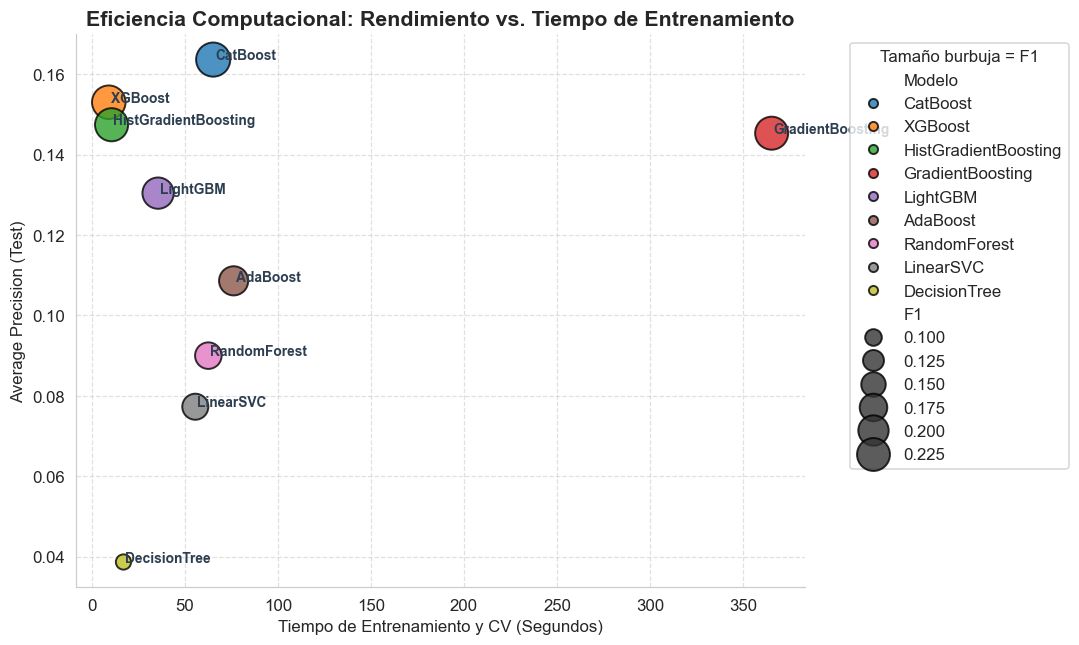

In [12]:
# RENDIMIENTO VS TIEMPO 
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_rank, 
    x='Tiempo_s', 
    y='AP_test', 
    hue='Modelo', 
    size='F1', 
    sizes=(100, 500), 
    palette=color_map, 
    alpha=0.8, 
    edgecolor='black'
)

# Añadir etiquetas de los modelos cerca de cada burbuja
for i, row in df_rank.iterrows():
    plt.text(row['Tiempo_s'] + 1, row['AP_test'], row['Modelo'], 
             fontsize=9, color='#2c3e50', weight='bold')

plt.title('Eficiencia Computacional: Rendimiento vs. Tiempo de Entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo de Entrenamiento y CV (Segundos)')
plt.ylabel('Average Precision (Test)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Tamaño burbuja = F1')
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig('benchmark_eficiencia.png', dpi=150)
plt.show()